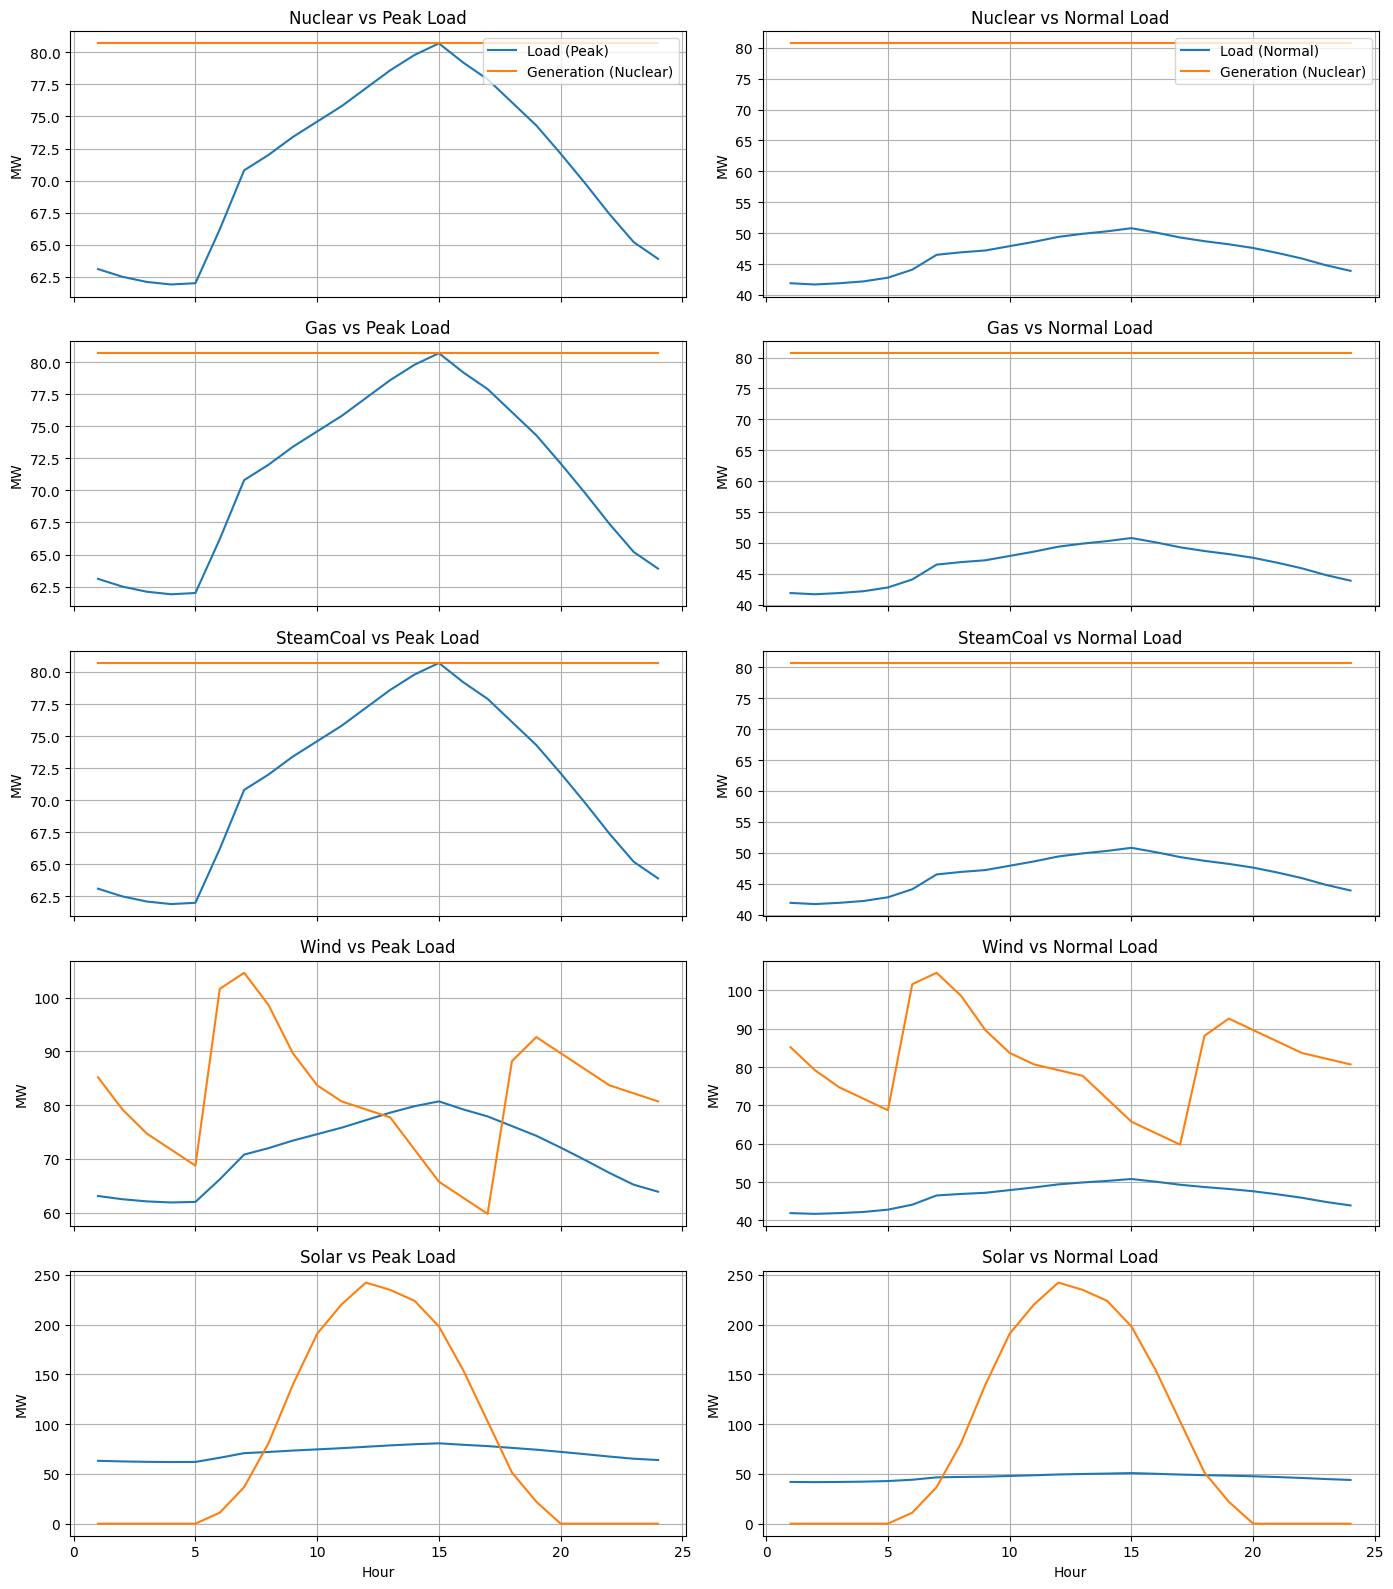

In [3]:
import numpy as np
import matplotlib.pyplot as plt


load_peak = np.array([63.1,62.5,62.1,61.9,62.0,66.2,70.8,72.0,73.4,74.6,75.8,77.2,78.6,79.8,80.7,79.2,77.9,76.1,74.3,72.1,69.8,67.4,65.2,63.9])
load_norm = np.array([41.9,41.7,41.9,42.2,42.8,44.1,46.5,46.9,47.2,47.9,48.6,49.4,49.9,50.3,50.8,50.1,49.3,48.7,48.2,47.6,46.8,45.9,44.8,43.9])



hours = np.arange(1, 25)

Pmax_peak = load_peak.max()

CF_solar = 0.22
CF_wind  = 0.54
CF_nuclear = 0.90
CF_gas = 0.87
CF_steam = 0.82

CF = {
    "Solar": CF_solar,
    "Wind": CF_wind,
    "Nuclear": CF_nuclear,
    "Gas": CF_gas,
    "SteamCoal": CF_steam
}

Creq = {k: Pmax_peak / v for k, v in CF.items()}  # MW


gen = {
    "Nuclear": np.ones(24) * Pmax_peak,
    "Gas": np.ones(24) * Pmax_peak,
    "SteamCoal": np.ones(24) * Pmax_peak,
    "Wind": Creq["Wind"] * wind,
    "Solar": Creq["Solar"] * solar
}

techs = ["Nuclear", "Gas", "SteamCoal", "Wind", "Solar"]

fig, axes = plt.subplots(nrows=len(techs), ncols=2, figsize=(14, 3.2*len(techs)), sharex=True)

for i, t in enumerate(techs):
    ax = axes[i, 0]
    ax.plot(hours, load_peak, label="Load (Peak)")
    ax.plot(hours, gen[t], label=f"Generation ({t})")
    ax.set_ylabel("MW")
    ax.set_title(f"{t} vs Peak Load")
    ax.grid(True)
    if i == 0:
        ax.legend(loc="upper right")

    ax = axes[i, 1]
    ax.plot(hours, load_norm, label="Load (Normal)")
    ax.plot(hours, gen[t], label=f"Generation ({t})")
    ax.set_ylabel("MW")
    ax.set_title(f"{t} vs Normal Load")
    ax.grid(True)
    if i == 0:
        ax.legend(loc="upper right")

for ax in axes[-1, :]:
    ax.set_xlabel("Hour")

plt.tight_layout()
plt.show()
